#task 1
1. Kendi Value sınıfını yaz, toplama ve çarpma ile başla. Her yeni Value, kendisini üreten Value'ları ve hangi işlemden çıktığını saklasın. İstersen videodaki gibi computation graph'i graphviz ile çizdir. (19:09 - 32:10)

value da normalde herhangi bir python integeri tutuyor fakat boyle bir sinif olusturulmasinin sebebi graf yapisi sayesinde hangi degerin hangi degeri kullanarak olusturuldugunu gorerek zincir kuralina uygun bir sekilde turev almak

In [39]:
import math # tanh exp ve pow fonksiyonu icin lazim
class Value:
  def __init__(self,data,_children=(),_op='',label=''): # L = a + a
    self.data = data
    self.grad =0.0 # Olusturulan nodeun cost functiona hic etkisi olmadigini varsayiyoruz cunku input nodelarda hata almayalim diye
    self._prev = set(_children)
    self._backward = lambda: None
    self._op=_op
    self.label = label

  def __repr__(self):
    children_labels = {child.label for child in self._prev}
    return f"Value(data={self.data},Children = {children_labels}, label = {self.label})" # mevcut dugumun degerini ve kimden geldigini gormek icin

  def __add__(self,other):
    #eger ki integer ile toplanmaya calisirsa value sinifina wrap edelim
    other = other if isinstance(other,Value) else Value(other)
    out = Value(self.data+other.data,(self,other),_op='+') # integer disi baska bir data type tanimladigimiz icin toplamayi tanimlamak gerekiyor

    def _backward():
      self.grad += 1.0* out.grad # += olmasi lazim cunku birden fazla ayni terim gelirse uzerine yazilmis oluyor
      other.grad += 1.0 * out.grad # chain ruleda onceden gelen terimi carpiyor bir de local derivative fakat toplama isleminin turevi 1 oldugu icin
      # bunu aslinda dagitmis oluyoruz nodelara
    out._backward = _backward # burada bir fonksiyon objesi olusturuyoruz L.grad = 1 set ediltikten sonra cagrilmasi gerekiyor ki backprop yapilsin
    # aksi halde 0 olur
    return out


  def __rmul__(self,other): #other * self
    return self*other
  def __mul__(self,other):
    other = other if isinstance(other,Value) else Value(other) # L = a + a -> dl/da = 2
    out = Value(self.data*other.data,(self,other),_op='*')

    def _backward():
      self.grad += other.data * out.grad # out = self.data * other.data oldugundan dolayi local derivate other.data
      other.grad += self.data * out.grad # ayni sekil fakat tam tersi

    out._backward = _backward
    return out

  #2. task icin lazim
  def tanh(self):
    n = self.data
    t = (math.exp(2*n)-1)/(math.exp(2*n)+1)
    out = Value(t,(self,),'tanh')

    def _backward():
      self.grad += (1-t**2) * out.grad          # out = [e^(2*self.data)-1]/[e^(2*self.data+1)] -> turevini aldiginda local derivative (1-t**2) oluyor
    out._backward = _backward
    return out

  def exp(self): ## tanhi parcalamak tamamen opsiyonel isin sonunda yaptiklari islem ayni
    out = Value(math.exp(self.data),(self,),'exp')

    def _backward():
      self.grad += out.data * out.grad
    out._backward = _backward
    return out

  def __neg__(self):
    return self * -1

  def __sub__(self,other):
    return self + (-other)
  def __truediv__(self,other): # bolme demek bolen * bolunen**-1 demek
    return self * other**-1

  def __pow__(self,other):
    assert isinstance(other,(int,float)), "only int/float powers supported"
    out = Value(self.data**other,(self,),'pow') # a - b = > a+ (-b)

    def _backward(): # power rule
      self.grad += other*(self.data**(other-1)) * out.grad
    out._backward = _backward
    return out


  def backward(self):

        # topological order all of the children in the graph
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)

        # go one variable at a time and apply the chain rule to get its gradient
        self.grad = 1
        for v in reversed(topo):
            v._backward()


a = Value(2);a.label = 'a'
b = Value(4);b.label = 'b'
c = a*b;c.label = 'c'
c

Value(data=8,Children = {'a', 'b'}, label = c)

In [40]:
from graphviz import Digraph
def trace(root): # util icin
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root, format='svg', rankdir='LR'):
    """
    format: png | svg | ...
    rankdir: TB (top to bottom graph) | LR (left to right)
    """
    assert rankdir in ['LR', 'TB']
    nodes, edges = trace(root)
    dot = Digraph(format=format, graph_attr={'rankdir': rankdir}) #, node_attr={'rankdir': 'TB'})

    for n in nodes:
        dot.node(name=str(id(n)), label = "{ data %.4f | grad %.4f }" % (n.data, n.grad), shape='record')
        if n._op:
            dot.node(name=str(id(n)) + n._op, label=n._op)
            dot.edge(str(id(n)) + n._op, str(id(n)))

    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot

#task 2
2. Otomatikleştirmeden önce gradient'leri videodaki iki örnekte elle doldur: önce basit ifade (32:10 - 51:10), sonra tek bir neuron. Neuron örneğinde tanh'ı Value'ya ekleyeceksin. Chain rule'u burada içselleştireceksin. (52:52 - 1:09:02)


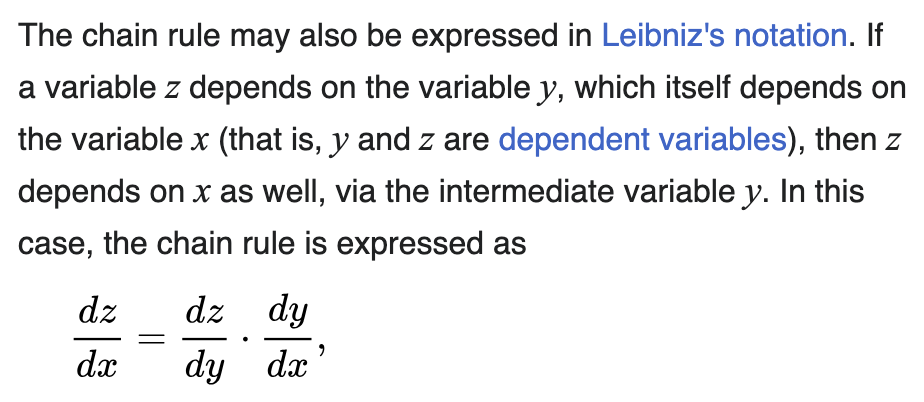

asagidaki sezgisel aciklamada zincir kuralinin temel felsefesi anlatiliyor:

bir araba bisikletten 4 kat hizliysa ve bir bisiklet bir insandan 2 kat daha hizliysa o halde araba bir insandan 4*2 = 8 kat hizlidir.
Geriye dogru carpma islemi yapiliyor

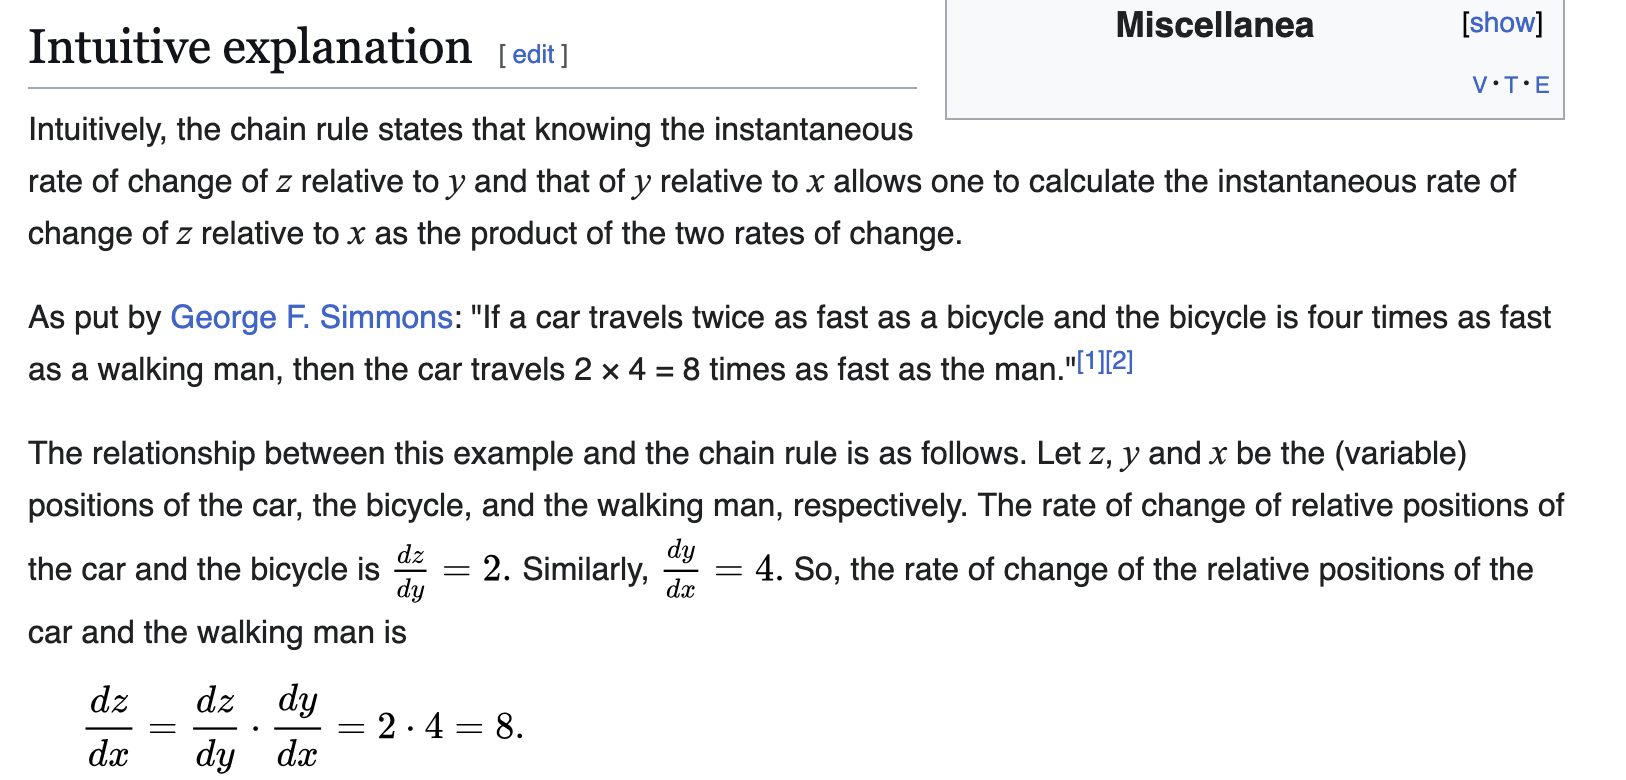

In [52]:
def lol():
  h = 0.001
  a = Value(2.0,label='a')
  b = Value(-3.0,label='b')
  c = Value(10.0,label='c')
  d = a*b;d.label='d'
  e = d+c; e.label='e'
  f = Value(-2.0,label='f')
  L= d*f;L.label='L'
  L1=L.data


  a = Value(2.0,label='a')
  b = Value(-3.0,label='b')
  b.data+=h
  c = Value(10.0,label='c')
  d = a*b;d.label='d'
  e = d+c; e.label='e'
  f = Value(-2.0,label='f')
  L= d*f;L.label='L'
  L2=L.data


  print(f"{(L2-L1)/h}. LOL fonksiyonu sonucu")

lol()
h=0.001
# bu fonksiyon   b=-3 noktasi icin turev hesapliyor (dL/db) sonucu ise -4
# elle yapalim simdi zincir kurali kullanarak
# dL/db = dl/dd * dd/db bulmamiz gerek
# dl/dd=(((d+h)*f)-d*f)/h
# = (fd+hf-df)/h = f = dL/dd
# simdi dd/db bulalim (d= a*b)
# dd/db = (a*(b+h)-a*b)/h
# = (ab+ah-ab)/h = a = dd/db
# yani dL/db sonucumuz = f*a geliyor verdigimiz valuelari yerine koyarsak ise -2*2 = -4
# fonksiyon sonucu ile dogru tutuyor


-3.9999999999995595. LOL fonksiyonu sonucu


## task2nin devami MLP ornegi

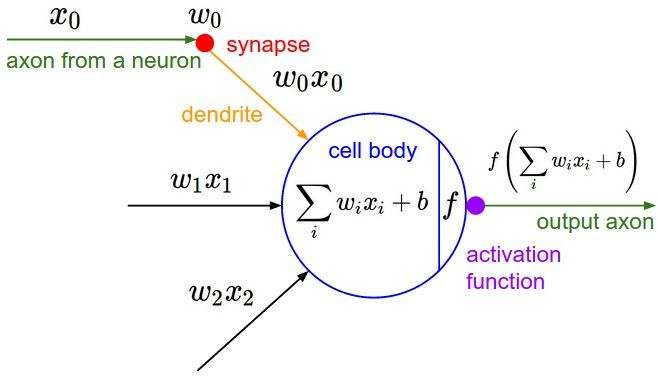

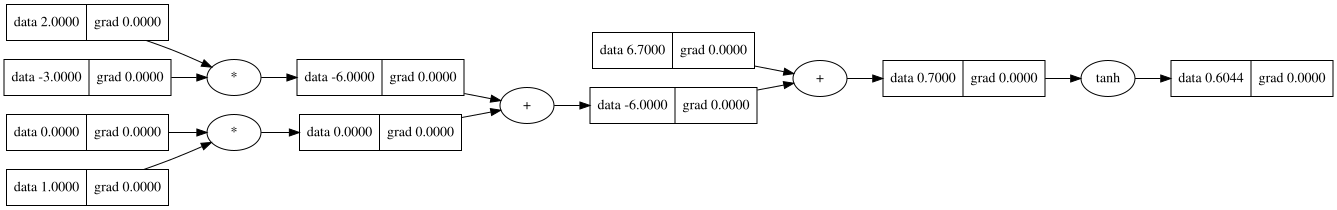

In [42]:
# inputs x1,x2
x1 = Value(2.0,
label='x1')
x2 = Value(0.0, label='x2')
# weights wl, w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.7, label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2. label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh();o.label = 'o' # tanh activation function bunun yerine relu sigmoid vs de kullanilabilir 0-1 range icerisine sıkıştırıyor
draw_dot(o)


# c = a + b
# ((a+h) + b - a - b) / h

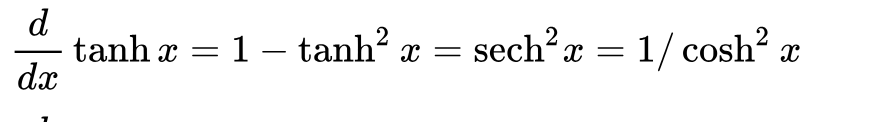

In [43]:
# baslangic olarak o grad =1 set etmemiz gerekir sonra geriye dogru saracagiz fakat activation functionunun turevine dikkat
# etmek lazim cunku carpma veya toplama kadar basit degil

o.grad =1.0
# o = tanh(n)
# do/dn = dtanh(n)/dn = 1-o**2
n.grad = 1-o.data**2
# n dugumunden geriye dogru gittigimizde toplama isareti goruyoruz toplama isareti gradi degistirmiyor sadece yayilmasini sagliyor
# o halde
x1w1x2w2.grad = n.grad
b.grad = n.grad
x1w1.grad = x1w1x2w2.grad # yine toplama var
x2w2.grad = x1w1x2w2.grad # yine toplama var
x2.grad = w2.data * x2w2.grad
w2.grad = x2.data * x2w2.grad

x1.grad = w1.data * x1w1.grad
w1.grad = x1.data * x1w1.grad

# task 3
3. backward() metodunu yaz: çıktının gradient'ini 1 yap, node'ları ters topological sırayla gez, her node'da chain rule uygula. Bir değişken birden fazla yerde kullanılıyorsa gradient'leri topla, üzerine yazma. (1:09:02 - 1:27:05)



In [44]:
# Value class'ina yazildi

# task 4
4. tanh'ı parçala: exp, bölme ve pow operasyonlarını ekle, aynı gradient'leri aldığını göster. Sonra doğrula: aynı ifadeyi aynı değerlerle hem backward() ile hem geçen haftaki numerical derivative ile hem de PyTorch ile hesapla, üçünün eşleştiğini göster. (1:27:05 - 1:43:55)

In [53]:
# inputs x1,x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights wl, w2
w1 = Value(-3.0, label='w1')
W2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label =  'x1w1x2w2'
n = x1w1x2w2 + b; n.label = 'n'

######3 exp pow ve div kullanarak parcaladik
e = (2*n).exp()
o = (e - 1) / (e + 1)
#######

o.label = 'o'
o.backward()


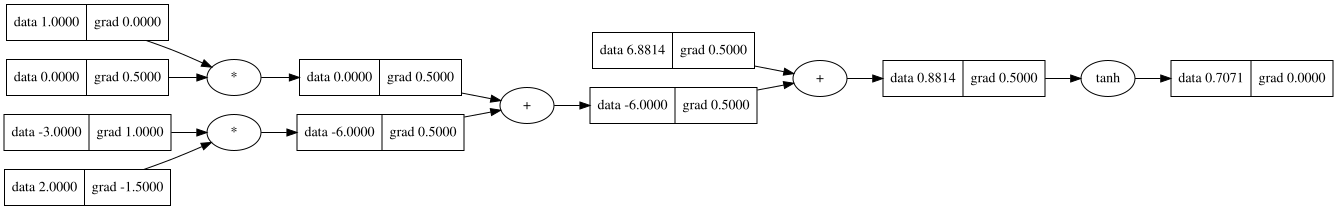

In [56]:
draw_dot(o)

In [55]:
#### tanh
o = n.tanh() ; o.label = 'o'

In [57]:
 import torch
 x1 = torch.Tensor( [2.0]).double()               ; x1. requires_grad = True
 x2 = torch.Tensor([0.0]).double()                ; x2.requires_grad = True
 w1 = torch.Tensor([-3.0]).double()               ; w1.requires_grad = True
 w2 = torch.Tensor([1.0]).double()                ; w2.requires_grad = True
 b = torch.Tensor([6.8813735870195432]).double()  ; b.requires_grad = True
 n = x1*w1 + x2*w2 + b
 o = torch.tanh(n)
 print(o.data.item())
 o.backward()
 print('---')
 print('x2', x2.grad.item( ))
 print('w2' ,w2.grad.item())
 print('x1' ,x1.grad.item())
 print('w1' ,w1.grad.item())

0.7071066904050358
---
x2 0.5000001283844369
w2 0.0
x1 -1.5000003851533106
w1 1.0000002567688737


#task 5
5. Videodaki sırayı izleyerek Neuron, Layer ve MLP sınıflarını kur. Parametreleri tek listede topla, videodaki küçük veri setiyle eğit, loss'un adım adım düştüğünü göster. Her adımda gradient'leri sıfırlamayı unutma, videodaki meşhur bug. (1:43:55 - 2:14:03)

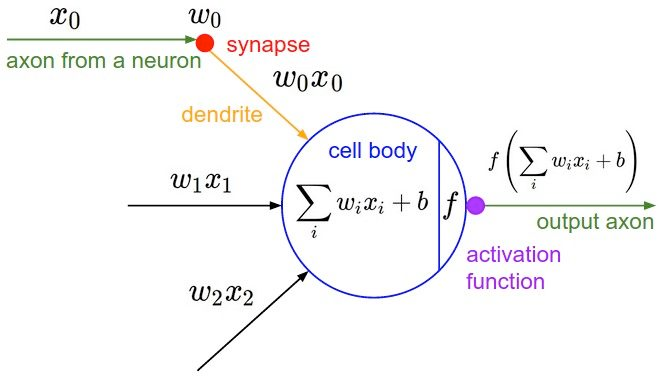

In [51]:
import numpy as np
class Neuron:
  def __init__(self,nin):
    self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
    self.b = Value(random.uniform(-1,1))

  def __call__(self,x):
    # w *x + b gecen hafta yaptigimzi dot product islemi
    act = sum(wi*xi for wi,xi in zip(self.w,x)) + self.b
    out = act.tanh()
    return out

#orn
x = [2.0,3.0]
n = Neuron(2)
n(x)

NameError: name 'random' is not defined